<a href="https://colab.research.google.com/github/blsparks/Diabetes_Readmission/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Necessary Libraries


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load the Dataset


In [65]:
df = pd.read_csv('diabetic_data.csv')

# Mapping Diagnostic Codes

Since the dataset contains hundreds of ICD-9 diagnostic codes, I mapped them into 9 categories to prevent the model from caring too much about categories that appear less frequently.

In [66]:
def icd9(code):
    try:
        val = float(code)
        if 390 <= val <= 459 or val == 785:
            return 'Circulatory'
        elif 460 <= val <= 519 or val == 786:
            return 'Respiratory'
        elif 520 <= val <= 579 or val == 787:
            return 'Digestive'
        elif 250 <= val < 251:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif 580 <= val <= 629 or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(icd9)

# Data Cleaning
Before cleaning the data, I looked at potential problems. I noticed that weight replaces empty values with "?" and after looking through the low number of nulls, I decided to replace "?" with nulls and convert the age ranges to a value between the range so the model could read it

In [67]:

df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [68]:
print(df.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [69]:
df = df.replace('?', np.nan)

In [70]:
age_int = {'[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45,
          '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95}
df['age'] = df['age'].replace(age_int)

In [71]:
print(df.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

# Drop Unnecessary Columns
I dropped columns that were either purely "noise" (like unique IDs) or had excessive missing values that would not benefit the model. For the remaining categorical features, I replaced empty values with 'Unknown'. This prevents the loss of data and allows the model to treat missingness as a potential pattern to be trained on.

In [72]:
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'patient_nbr', 'encounter_id'], axis=1, inplace=True)

In [73]:
cols_to_fix = ['payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'race']
df[cols_to_fix] = df[cols_to_fix].fillna('Unknown')


In [74]:
print(df.isnull().sum())

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

# Encode Categorical Variables

I kept the 6 most frequent medical specialties and mapped the less frequent specialties to "Other" to prevent overfitting. Dummy Variables needed to be encoded into integers (1 or 0) and drop_first to avoid multicollinearity.

In [75]:
top_specialties = ['InternalMedicine', 'Emergency/Trauma', 'Family/GeneralPractice',
                   'Cardiology', 'Surgery-General', 'Nephrology']

df['medical_specialty'] = df['medical_specialty'].apply(lambda x: x if x in top_specialties else 'Other')

In [76]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)


# Model Training
I split data into a training and test split. Logistic Regression needs to be scaled so features with larger numbers dont overpower features that only contain 0 or 1. Comparing models, logistic regression was slightly less precise, but more importantly only caught 44% of readmissions compared to random forest which caught 52% of readmissions. Lowering the threshold to .4 instead of .5 to make the model less precise but recall increase to .76 is better for health related issues to not miss patients who need help.

In [77]:
X = df_encoded.drop(columns=['readmitted_>30', 'readmitted_NO'])
y = df_encoded['readmitted_NO'].apply(lambda x: 0 if x == 1 else 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [78]:
ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scale, y_train)
lr_preds = lr.predict(X_test_scale)
print("Logistic Regression")
print(classification_report(y_test, lr_preds))



Logistic Regression
              precision    recall  f1-score   support

           0       0.62      0.78      0.69     10952
           1       0.63      0.44      0.52      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.60     20354
weighted avg       0.62      0.62      0.61     20354



In [79]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest")
print(classification_report(y_test, rf_preds))

Random Forest
              precision    recall  f1-score   support

           0       0.64      0.73      0.69     10952
           1       0.63      0.52      0.57      9402

    accuracy                           0.64     20354
   macro avg       0.64      0.63      0.63     20354
weighted avg       0.64      0.64      0.63     20354



In [80]:
rf_thresh = rf.predict_proba(X_test)[:, 1]
rf_recall = (rf_thresh > 0.40).astype(int)
print("Recall Optimized Random Forest")
print(classification_report(y_test, rf_recall))

Recall Optimized Random Forest
              precision    recall  f1-score   support

           0       0.71      0.49      0.58     10952
           1       0.56      0.76      0.65      9402

    accuracy                           0.61     20354
   macro avg       0.63      0.62      0.61     20354
weighted avg       0.64      0.61      0.61     20354



# Plotting for Insights

Based on the graph, patients who need more testing and medications have a higher chance for readmission. By identifying these features, healthcare providers can be better equiped to identify patients that are likely to come back and be prepared to give support when that happens.

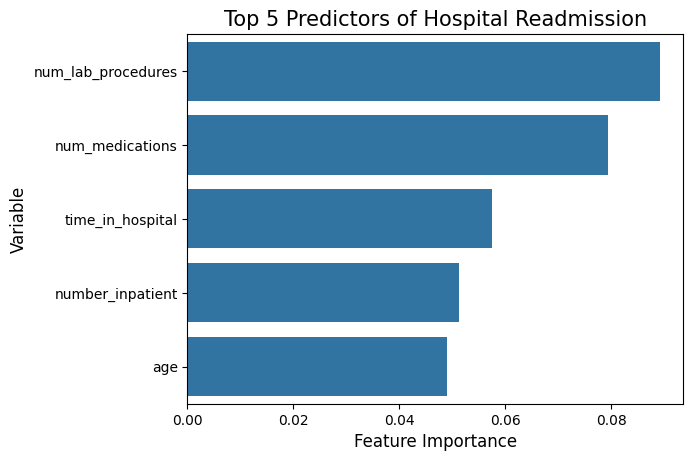

In [81]:
top_5 = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
sns.barplot(x=top_5.values, y=top_5.index)
plt.title("Top 5 Predictors of Hospital Readmission", fontsize=15)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.show()